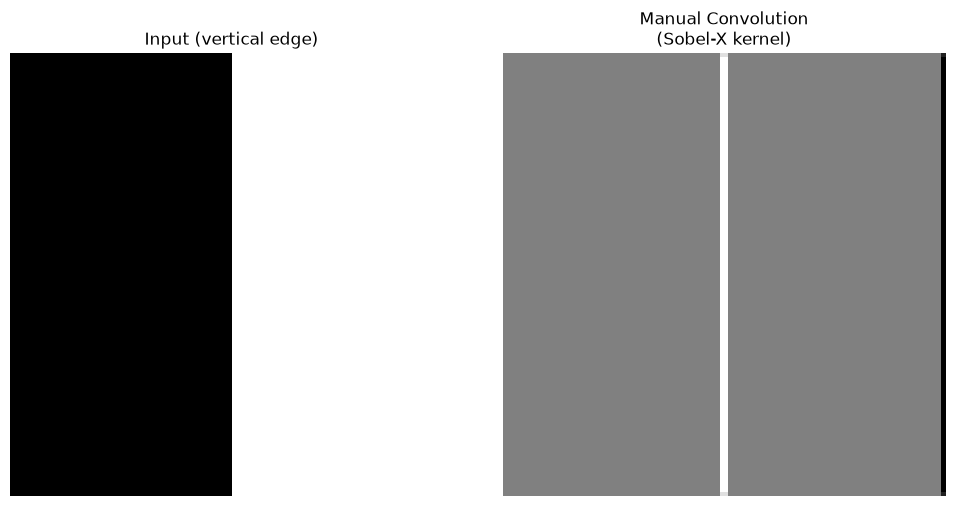

Input shape: (100, 100)
Output shape: (100, 100)
Kernel: 3x3 -> params if this were LEARNED: 9 weights (+1 bias if used)


In [3]:
# ============================================
# Phase 2 — Day 15: Convolution as a Learned Operation
# Manual 2D convolution -- literally the same sliding-window operation
# as Day 11's Sobel kernel, just written out explicitly this time
# ============================================

import numpy as np 
import cv2 
import matplotlib.pyplot as plt 

def conv2d_manual(image, kernel, stride=1, padding=0):
    #padding the image with zeros (same ideas as your : P = {k - 1}/2 for "same " output size)
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)))

    H, W = image.shape
    K = kernel.shape[0] 

    out_h = (H - K)// stride + 1
    out_w = (W - K)// stride + 1 
    output = np.zeros(( out_h, out_w))

    for i in range(out_w):
        for j in range(out_w):
            row_start = i* stride 
            col_start = j* stride
            region = image[row_start : row_start+K, col_start:col_start + K]
            output[i, j]= np.sum(region *kernel)

    return output 

# The Exact  Sobel-X kernel from day 11 a hand designed filter, same shape a CNN would learn
sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype = np.float64)

## Reuse a test image -- load any grayscale image you have, or generate a simple edge
test_img = np.zeros((100,100), dtype = np.float64)
test_img[:, 50:] = 255 

manual_result = conv2d_manual(test_img, sobel_x_kernel, stride = 1, padding=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Input (vertical edge)')
axes[0].axis('off')
axes[1].imshow(manual_result, cmap='gray')
axes[1].set_title('Manual Convolution\n(Sobel-X kernel)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Input shape: {test_img.shape}")
print(f"Output shape: {manual_result.shape}")
print(f"Kernel: 3x3 -> params if this were LEARNED: {sobel_x_kernel.size} weights (+1 bias if used)")

Manual output shape: (100, 100)
PyTorch output shape: (100, 100)
Max absolute difference: 0.00000000
Are they identical (within floating point tolerance)? True


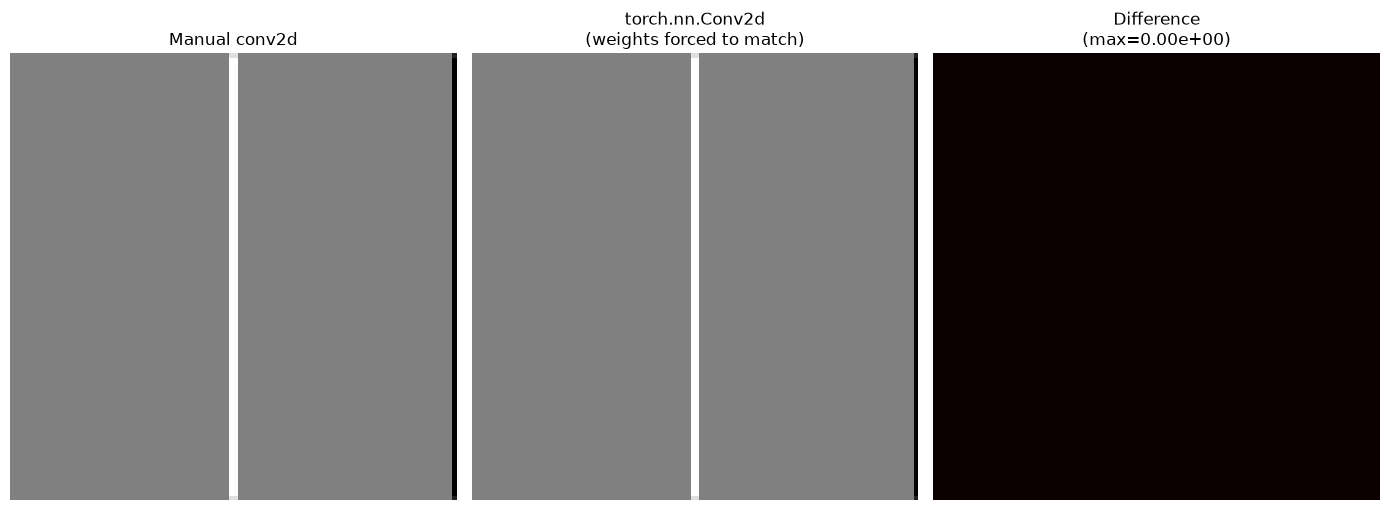

In [10]:
# ============================================
# Verify manual convolution against torch.nn.Conv2d
# ============================================

import torch 
import torch.nn as nn 

# PyTorch conv layers expect input shape: (batch, channels, height, width)
# and kernel shape: (out_channels, in_channels, kH, kW)
test_img_torch = torch.tensor(test_img, dtype= torch.float32).unsqueeze(0).unsqueeze(0)

conv_layer = nn.Conv2d(in_channels = 1, out_channels =1, kernel_size = 3, stride = 1, padding = 1, bias = False)

# Force PyTorch's conv layer to use the EXACT same Sobel weights,
# instead of random init -- so we're comparing the same math, not different kernels  
with torch.no_grad():
    conv_layer.weight = nn.Parameter(
        torch.tensor(sobel_x_kernel, dtype= torch.float32).unsqueeze(0).unsqueeze(0)
    )

torch_result = conv_layer(test_img_torch).squeeze().detach().numpy()

#compare
diff = np.abs(manual_result - torch_result)
print(f"Manual output shape: {manual_result.shape}")
print(f"PyTorch output shape: {torch_result.shape}")
print(f"Max absolute difference: {diff.max():.8f}")
print(f"Are they identical (within floating point tolerance)? {np.allclose(manual_result, torch_result, atol=1e-4)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(manual_result, cmap='gray')
axes[0].set_title('Manual conv2d')
axes[0].axis('off')
axes[1].imshow(torch_result, cmap='gray')
axes[1].set_title('torch.nn.Conv2d\n(weights forced to match)')
axes[1].axis('off')
axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f'Difference\n(max={diff.max():.2e})')
axes[2].axis('off')
plt.tight_layout()
plt.show()


Randomly initalized kernel (before Training):
[[ 0.2548462   0.27666932 -0.07809083]
 [ 0.30620378 -0.07303452  0.06726357]
 [-0.16228501  0.19576089  0.29384765]]
Epoch   0  Loss: 66902.953125
Epoch  40  Loss: 13008.188477
Epoch  80  Loss: 2260.178955
Epoch 120  Loss: 306.530914
Epoch 160  Loss: 94.787659

Learned kernel (after training):
[[-1.1611422   0.0230275   1.170501  ]
 [-1.0837256  -0.29522127  1.3459831 ]
 [-1.5416336  -0.02105263  1.567023  ]]

Original Sobel-X kernel (never shown to the network):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


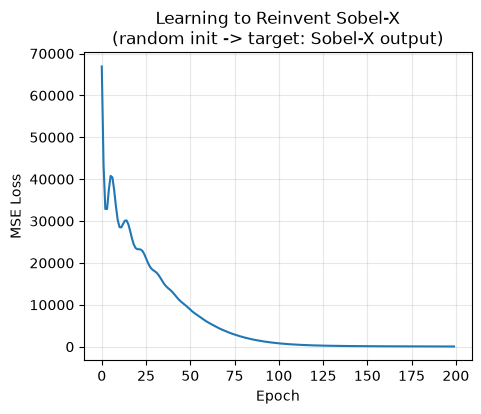

In [14]:
# ============================================
# Let backprop LEARN a kernel from scratch, no Sobel hint given
# Task: given the vertical-edge image, learn to reproduce the
# Sobel-X output -- but starting from random weights
# ============================================

torch.manual_seed(42)

# Fresh conv layer, RANDOM initialization this time (no cheating with Sobel weights)
learnable_conv = nn.Conv2d(in_channels= 1, out_channels= 1, kernel_size=3, stride=1, padding=1, bias= False)
print("Randomly initalized kernel (before Training):")
print(learnable_conv.weight.detach().numpy().squeeze())

# Target: what we WANT the network to learn to produce (Sobel-X's actual output)
target= torch.tensor(torch_result, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

optimizer = torch.optim.Adam(learnable_conv.parameters(), lr = 0.05)
loss_fn = nn.MSELoss()

loss_history = []
for epoch in range(200):
    optimizer.zero_grad()
    output = learnable_conv(test_img_torch)
    loss = loss_fn(output,target)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 40 == 0:
        print(f"Epoch {epoch:3d}  Loss: {loss.item():.6f}")

print("\nLearned kernel (after training):")
print(learnable_conv.weight.detach().numpy().squeeze())
print("\nOriginal Sobel-X kernel (never shown to the network):")
print(sobel_x_kernel)

plt.figure(figsize=(5,4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning to Reinvent Sobel-X\n(random init -> target: Sobel-X output)')
plt.grid(alpha=0.3)
plt.show()